# DQN with CartPole-v2 Environment

This notebook loads [config.yaml](config.yaml) and trains the `QAgent` on `CartPole-v1` using the Gymnassium API for envrionment.

CartPole has a `Box(4,)` **observation space** and a `Discrete(2)` **action space**, so DQN uses the continuous state and the native discrete actions while training, during analysis we break it down based on our analysis discretisation config to look at the various statistics.

## Imports

In [1]:
import sys, pathlib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Config-driven wiring: change config.yaml and it flows through these builders
# without editing the notebook. Hankel analysis is driven by analysis.hankel_sweep
# in config.yaml (dispatched inside the training loop), so no Hankel import here.
from experiment import load_config, build_env, build_agent, train, make_run_logger
from analysis.registry import resolve_methods
from analysis.low_rank.rank import row_rank_property_check
from analysis.visualisations.heatmaps import plot_matrix_heatmap

## Reading the `config` file

In [2]:
cfg = load_config("config.yaml")   # loads yaml, resolves device, seeds torch/numpy
print("device:", cfg["experiment"]["_device"])
cfg

device: cuda


{'experiment': {'name': 'dqn_cartpole',
  'seed': 52,
  'device': 'cuda',
  'save_artifacts': True,
  '_device': 'cuda'},
 'environment': {'name': 'CartPole-v1',
  'render_mode': None,
  'discrete_config': None,
  'normalise': {'action': {},
   'state': {'min': [-4.8, -10, -0.41887903, -10],
    'max': [4.8, 10, 0.41887903, 10]}},
  'clip': {'action': False,
   'state': {'min': [None, -100, None, -100], 'max': [None, 100, None, 100]}}},
 'network': {'hidden_sizes': [128, 128]},
 'agent': {'replay_buffer_capacity': 100000,
  'batch_size': 128,
  'nn_learning_rate': 0.0005,
  'eps_start': 1.0,
  'eps_min': 0.01,
  'decay_rate': 0.99992,
  'discount_factor': 0.99,
  'TD_LR': 0.3,
  'buffer_util': 1,
  'gd_steps_ceil': 40,
  'grad_clip_norm': 10.0,
  'double': True},
 'training': {'no_episodes': 1500,
  'target_network_update_steps': 100,
  'train_frequency_steps': 50,
  'use_episode_training': True,
  'solved_reward': 475,
  'warmup_steps': 1500,
  'early_stopping_patience_eps': 50,
  'no

## Creating the Envrionment

In [3]:
env = build_env(cfg)
obs_dim = env.observation_space.shape[0]
n_actions = env.action_space.n
print("obs_dim:", obs_dim, "n_actions:", n_actions)

obs_dim: 4 n_actions: 2


## Creating the Agent

In [4]:
class QNetwork(nn.Module):
    """Maps a state (obs_dim,) -> Q-values (n_actions,). Built by QAgent via q_network(**nn_extra_kwargs)."""
    def __init__(self, in_dim, out_dim, hidden_sizes=(128, 128)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [5]:
# The net class + its derived dims are genuine code (not config keys), so they
# stay explicit; every agent hyperparameter comes from cfg["agent"] via build_agent.
nn_extra_kwargs = {
    "in_dim": obs_dim,
    "out_dim": n_actions,
    "hidden_sizes": cfg["network"]["hidden_sizes"],
}
agent = build_agent(cfg, env, QNetwork, nn_extra_kwargs)

## Analysis (Low Rank)

In [6]:
# Run artifacts (spectra figures, rewards/rank/hankel_sweep CSVs, trajectories,
# checkpoints) land under runs/<timestamp>/ when experiment.save_artifacts is set;
# otherwise logger is None and analysis renders inline. Hankel runs via the
# analysis.hankel_sweep config block (dispatched inside the training loop);
# generic methods (e.g. q_matrix_dqn) resolve from analysis/registry.py.
logger = make_run_logger(cfg)
if logger:
    print("run artifacts ->", logger.dir)

run artifacts -> /home/souparna/Low-Rank-RL-TL/experiments/dqn_cartpole/runs/20260707-141853


## Agent Training 

In [7]:
rewards = train(cfg, agent, env, run_logger=logger)

  0%|          | 0/1500 [00:00<?, ?it/s]

episode 0 avg_rewarg: 13.0
****************************Q-function****************************
eff_rank: 2, stable_rank: 1.13, spikiness: 3.26, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: row min=4.366e-06 max=0.001463 (uniform 0.0002441) | col min=0.5 max=0.5 (uniform 0.5)
coherence score: row=5.992 col=1


  0%|          | 1/1500 [00:00<18:42,  1.34it/s]

episode 10 avg_rewarg: 25.4
episode 20 avg_rewarg: 18.0
episode 30 avg_rewarg: 22.9
episode 40 avg_rewarg: 26.2
episode 50 avg_rewarg: 18.5
****************************Q-function****************************
eff_rank: 2, stable_rank: 1.13, spikiness: 3.26, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: row min=4.366e-06 max=0.001463 (uniform 0.0002441) | col min=0.5 max=0.5 (uniform 0.5)
coherence score: row=5.992 col=1


  3%|▎         | 51/1500 [00:01<00:24, 58.94it/s]

...

episode 740 avg_rewarg: 499.1


 50%|█████     | 750/1500 [01:29<01:42,  7.30it/s]

episode 750 avg_rewarg: 500.0
****************************Q-function****************************
eff_rank: 1, stable_rank: 1.01, spikiness: 2.93, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: row min=3.154e-12 max=0.001854 (uniform 0.0002441) | col min=0.4334 max=0.5666 (uniform 0.5)
coherence score: row=7.592 col=1.133


 50%|█████     | 756/1500 [01:35<01:33,  7.92it/s]

Average trajectory (episode total) reward for 50 episodes is 475.1
Triggering Early Stopping !!
run artifacts saved under /home/souparna/Low-Rank-RL-TL/experiments/dqn_cartpole/runs/20260707-141853


## Training and Analysis Plots (now with pi*(theeta))

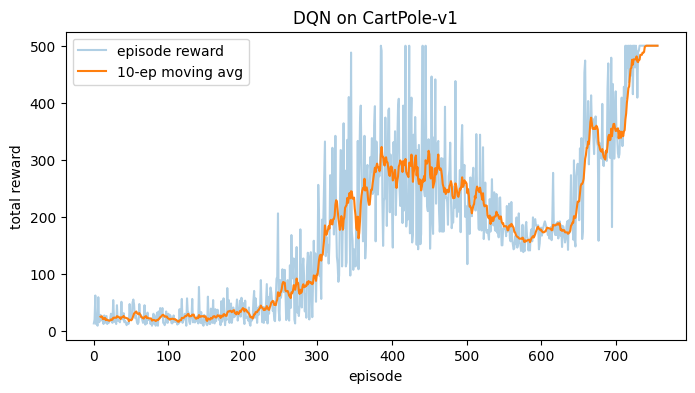

In [8]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("DQN on CartPole-v1")
plt.legend()
if logger:
    plt.savefig(logger.dir / "reward_curve.png", dpi=150, bbox_inches="tight")
plt.show()

Q-function


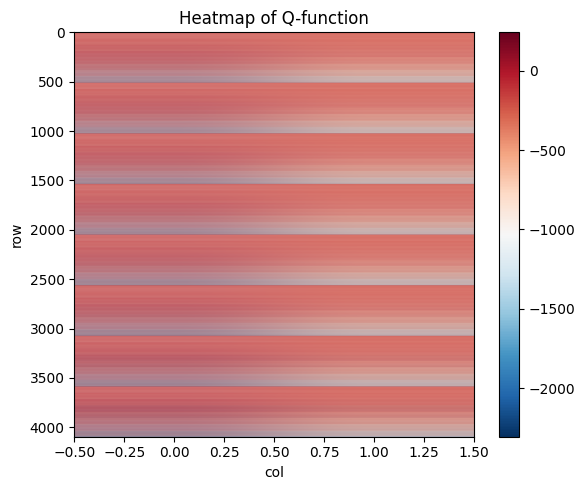

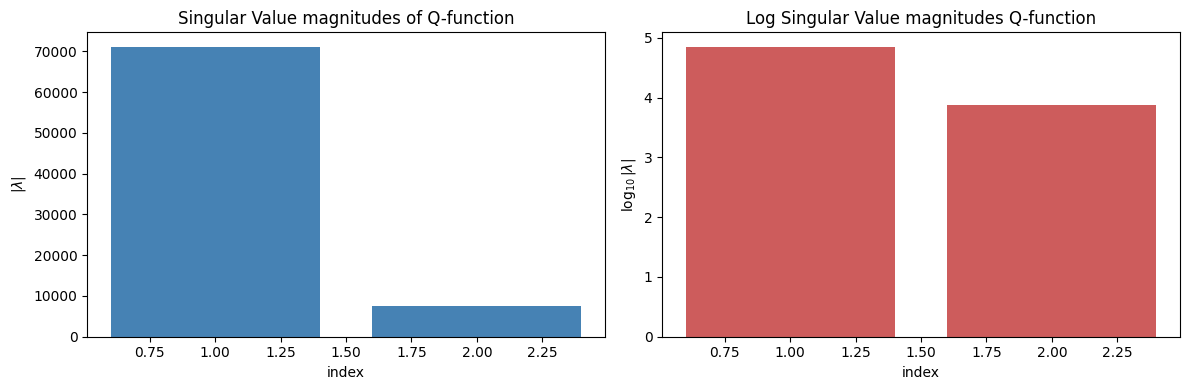

eff_rank: 1, stable_rank: 1.01, spikiness: 2.92, shape: (4096, 2), non-zero rows :4096, non-zero cols:2
top-r leverage spread: row min=4.987e-10 max=0.001847 (uniform 0.0002441) | col min=0.4332 max=0.5668 (uniform 0.5)
coherence score: row=7.566 col=1.134


In [9]:
# Post-training: run the generic per-matrix methods (e.g. q_matrix_dqn) + any
# post_methods on the final policy, showing heatmap + spectrum for each. Hankel
# already ran every ep_freq during training via hankel_sweep.
methods = resolve_methods(cfg["analysis"].get("methods", []) + cfg["analysis"].get("post_methods", []))
for method, names in methods:
    results = method(agent=agent, env=env)
    if not isinstance(results, tuple):
        results = (results,)
    for matrix, name in zip(results, names):
        print(name)
        plot_matrix_heatmap(matrix, name, save_to=logger.figure_path(f"{name} heatmap") if logger else None)
        r, sr, spk, shape, irs, ics, rc, cc, nzr, nzc = row_rank_property_check(matrix, name, save_to=logger.figure_path(name) if logger else None)
        print(f"eff_rank: {r}, stable_rank: {sr:.2f}, spikiness: {spk:.2f}, shape: {shape}, non-zero rows :{nzr}, non-zero cols:{nzc}")
        print(f"top-r leverage spread: row min={irs.min():.4g} max={irs.max():.4g} (uniform {1.0/shape[0]:.4g}) | col min={ics.min():.4g} max={ics.max():.4g} (uniform {1.0/shape[1]:.4g})")
        print(f"coherence score: row={rc:.4g} col={cc:.4g}")

## Greedy rollout video

Record one greedy (`act_greedy`) episode of the trained `agent` and display it inline. The eval env is rebuilt with `render_mode="rgb_array"` so frames can be captured.

In [10]:
# Greedy rollout video of the trained agent
from analysis.visualisations.rollout_video import record_greedy_episode
from IPython.display import Video
import glob

video_dir = "videos"
eval_env = build_env(cfg, render_mode="rgb_array")
prefix = record_greedy_episode(agent, eval_env, video_dir, episode=0, seed=cfg["experiment"]["seed"])
mp4 = sorted(glob.glob(f"{video_dir}/{prefix}-*.mp4"))[-1]
print("saved:", mp4)
Video(mp4, embed=True)

/home/souparna/Low-Rank-RL-TL/.venv/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/souparna/Low-Rank-RL-TL/experiments/dqn_cartpole/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


saved: videos/ep0-episode-0.mp4
